# Method 2: Angles

This method uses *angles* to determine the **edges connected to a node** (i.e. neighbors). Detailed explanation of the idea, assumptions and implementation can be found in [Week 3 Report](../../reports/week3.md#triangular-ruler-method-2-angles).

Quick table of contents:
- **A) Pre-Processing** — Data is processed from `.gro` file
- **B) 3-D Modelling** — Algorithm for blocking, finding neighbors and Matplotlib visualisation 
- **C) Error In 3-D Modelling** — Visualisation of the error in the 3-D
- **D) 2-D Modelling** — Original blocking algorithm (no errors and works perfectly)

---

## A) Pre-Processing

Data is processed from the `.gro` file. Midpoints of oxygen is found considering periodic boundary conditions.

In [1]:
# Dependencies
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from numpy import linalg as LA

# Matplotlib settings
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 200

# %matplotlib ipympl

In [2]:
"""
Reads the npt-HK4.gro and returns the following:

data(pd.Dataframe): A dataframe that contains Residue ID(res_id) and Name(res_name), Atom Name (atom_name) and ID(atom_id): the atom coordinates(x, y, z) and velocity components(Vx, Vy, Vz)
title(str): The title of the .gro file
num_atoms(str): The number of atoms
box_dimensions(list): The simulation box dimensions in a list of [x,y,z] 

"""
# Setting column specifications
colspecs = [
    (0, 5),
    (5, 8),
    (8, 15),
    (15, 20),
    (20, 28),
    (28, 36),
    (36, 44),
    (44, 52),
    (52, 60),
    (60, 68),
]

# Setting names of columns
names = ["res_id", "res_name", "atom_name", "atom_id", "x", "y", "z", "Vx", "Vy", "Vz"]

# Reading data
data = pd.read_fwf(
    "../../data/npt-HK4.gro",
    colspecs=colspecs,
    names=names,
    skiprows=2,
    skipfooter=1,
)

# Problem: after atom id 99999, it reverts back to 0. The following solves this:
for i in data.index:
    if i >= 99999:
        data.at[i, "atom_id"] += 100000

# Reading Title, number of atoms and box_dimensions
with open("../../data/npt-HK4.gro", "rb") as f:
    title = f.readline().decode().strip()  # First line of .gro file
    num_atoms = f.readline().decode().strip()  # Second line of .gro file

    # Last line of file
    f.seek(-2, 2)
    while f.read(1) != b"\n":
        f.seek(-2, 1)
    box_dimensions = f.readline().decode().strip().split()
    box_dimensions = list(map(float, box_dimensions))


# Checking
# print(data.tail())
# print(f"Title: {title}")
# print(f"Number of atoms: {num_atoms}")
# print(f"Box dimensions: {box_dimensions}")

### Finding midpoints of Oxygen atoms

In [3]:
# Algorithm to compute midpoints
def compute_midpoints_df(filtered_data, box_length):
    """
    Given a multi-indexed DataFrame (filtered_data) and box_length,
    returns a DataFrame with columns ['res_id', 'mid_x', 'mid_y', 'mid_z']
    containing the midpoints between O1 and O2 atoms for each residue.
    """
    def minimum_image(dx, box_length):
        reciprocal_half_box = 1.0 / (0.5 * box_length)
        k = int(dx * reciprocal_half_box)
        return dx - k * box_length

    def midpoint_pbc(p1, p2, box_length):
        dx = p2 - p1
        dx_mic = minimum_image(dx, box_length)
        midpoint = (p1 + 0.5 * dx_mic) % box_length
        return midpoint

    midpoints = []
    for res_id in filtered_data.index.get_level_values(0).unique():
        try:
            o1 = filtered_data.loc[(res_id, "O1")]
            o2 = filtered_data.loc[(res_id, "O2")]
            mx = midpoint_pbc(o1['x'], o2['x'], box_length)
            my = midpoint_pbc(o1['y'], o2['y'], box_length)
            mz = midpoint_pbc(o1['z'], o2['z'], box_length)
            midpoints.append({'res_id': res_id, 'mid_x': mx, 'mid_y': my, 'mid_z': mz})
        except KeyError:
            # Skip residues without both O1 and O2
            continue

    return pd.DataFrame(midpoints)

In [4]:
# !!! If an error occurs, re-run all cells from top !!!
data.drop(columns=["Vx", "Vy", "Vz"], inplace=True)  
data.set_index(['res_id', 'atom_name'], inplace=True)

# Extract box length from box_dimensions string 
box_length = box_dimensions[0]
# Midpoint of all oxygen molecules
midpoints_df = compute_midpoints_df(data, box_length)

# Add midpoint coordinates as new columns to filtered_data at the residue level
for idx, row in midpoints_df.iterrows():
    data.loc[(row['res_id'], slice(None)), 'midO_x'] = row['mid_x']
    data.loc[(row['res_id'], slice(None)), 'midO_y'] = row['mid_y']
    data.loc[(row['res_id'], slice(None)), 'midO_z'] = row['mid_z']


# Checking
# data

---

## B) 3-D Modelling

Algorithm for blocking, and finding neighbors is implemented. Matplotlib is used to visualise the graph network.

- **IMPORTANT:** The **blocking algorithm has ERROR** in finding neighbors when there is a molecule **directly above/below (i.e. within 4 quadrants)** as *viewed from the selected node*.

In [5]:
# --------------------------------------
# Helper functions
# --------------------------------------

# Nearest neighbor function
def find_sort_neighbors_distances(node: list, x: np.ndarray, y: np.ndarray, z: np.ndarray) -> tuple:
    """
    Calculate Euclidean distances of all neighbors from a given node in 3D space, alongside an ndarray of sorted indices from closest to furthest.
    
    Parameters:
    node (array-like): Coordinates of node [x, y, z].
    x (np.ndarray)   : x-coordinates of neighbors.
    y (np.ndarray)   : y-coordinates of neighbors.
    z (np.ndarray)   : z-coordinates of neighbors.
    
    Returns:
    tuple: Unsorted distances and sorted indices from closest to furthest of the nearest neighbors.
    """
    # Calculate Euclidean distances of all neighbors from the node
    distances = LA.norm(np.array([x - node[0], y - node[1], z - node[2]]), axis=0)
    
    # Returns unsorted distances and their indices
    return distances, np.argsort(distances)


# Calculate theta (θ) function, zenith (0 <= Φ <= π)
def find_thetas(node: list, z: np.ndarray, distances: np.ndarray, ) -> np.ndarray:
    """
    Calculate the angle theta (θ) of each neighbor, with respect to a selected node in a 3D space.
    
    Parameters:
    node (array-like): Coordinates of node [x, y, z].
    z (np.ndarray): z-coordinates of neighbors.
    distances (np.ndarray): Distances from the node to each point.

    Returns:
    np.ndarray: Array of angles (in radians) of each neighbor, with respect to a selected node.
    """
    # np.clip: ensures that values lie within [-1, 1]
    # np.where: takes into account division by zero 
    thetas = np.arccos(np.clip((z - node[2]) / distances, -1.0, 1.0))
    return thetas
        

# Calculate phi (Φ) function, azimuthal (-π < Φ <= π)
def find_phis(node: list, x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Calculate the angle phi (Φ) of each neighbor, with respect to a selected node in a 3D space.

    Parameters:
    node (list): Coordinates of the reference node [x, y, z].
    x (np.ndarray): x-coordinates of neighbors.
    y (np.ndarray): y-coordinates of neighbors.

    Returns:
    np.ndarray: Array of angles (in radians) of each neighbor, with respect to a selected node.
    """
    phis = np.arctan2(y - node[1], x - node[0])
    return phis

In [6]:
# --------------------------------------
# Data & Calculations
# --------------------------------------

# Parameters
n, low, high = midpoints_df["mid_x"].size, box_length, box_length
# Oxygen data
x = np.array(midpoints_df['mid_x'])
y = np.array(midpoints_df['mid_y'])
z = np.array(midpoints_df['mid_z'])
dl = 1.6 # Width, nm of a molecule (pre-calculated)
# Stacks the x, y, z coordinates into a 2D array
xyz = np.column_stack((x, y, z))
# Keep original for later plotting
x_copy = x.copy()
y_copy = y.copy()
z_copy = z.copy()


# Loop through every node and find their respective neighbors
nodes_neighbors = []
for nodes in xyz:
    node = nodes.tolist() # Converts current node to a list
    
    # Get sorted distances and indices
    distances, indices = find_sort_neighbors_distances(node, x, y, z) 
    # Sort x, y, z and distances
    x_temp, y_temp, z_temp, distances = x[indices], y[indices], z[indices], distances[indices]
    # Remove first element (the node itself)
    x_temp, y_temp, z_temp, distances = np.delete(x_temp, 0), np.delete(y_temp, 0), np.delete(z_temp, 0), np.delete(distances, 0)
    # Get sorted θ and φ
    thetas = find_thetas(node, z_temp, distances)
    phis = find_phis(node, x_temp, y_temp)


    # --------------------------------------
    # Simple Blocking Model
    # --------------------------------------
    # !!! Get the blocking portion in θ !!!
    d_theta = np.arctan(dl / (2 * distances))
    block1_thetas, block2_thetas = thetas - d_theta, thetas + d_theta
    
    # Slightly roundabout method of finding Φ's
    # Get the blocking portion, dx and dy of each neighbor 
    dx, dy = dl/2 * np.sin(phis), dl/2 * np.cos(phis)
    block1_x_phis, block1_y_phis = x_temp + dx, y_temp - dy
    block2_x_phis, block2_y_phis = x_temp - dx, y_temp + dy
    
    # !!! Get the blocking portion in Φ !!!
    block1_phis, block2_phis = find_phis(node, block1_x_phis, block1_y_phis), find_phis(node, block2_x_phis, block2_y_phis)

    # Converting phis to 0 < Φ < 2π
    phis = np.where(phis < 0, phis + 2 * np.pi, phis)
    block1_phis = np.where(block1_phis < 0, block1_phis + 2 * np.pi, block1_phis)
    block2_phis = np.where(block2_phis < 0, block2_phis + 2 * np.pi, block2_phis)
    # Correcting for case: Φ1 = 350° and Φ2 = 10°
    block2_phis = np.where(block1_phis > block2_phis, block2_phis + 2 * np.pi, block2_phis)
    
    # --------------------------------------
    # Blocking Algorithm
    # --------------------------------------
    # Note that this algorithm is INCOMPLETE, that is PRODUCES ERRORS near θ ≈ 0° and θ ≈ 180° (3-D)
    # However, Φ works perfectly (2-D)

    # Determines the indices of the neighbors that are blocked
    all_blocked_indices = []
    for i in range(len(block1_phis)):
        # Checks for the conditions:
        # 1. ((Φ1 < Φ < Φ2) | (Φ1 < Φ + 2π < Φ2)) &
        # 2. (θ1 < θ < θ2) &
        # 3. (neighbor distance > current neighbor distance)
        blocked_indices = np.where(
            (((phis >= block1_phis[i]) & (phis <= block2_phis[i])) | ((phis + 2*np.pi >= block1_phis[i]) & (phis + 2*np.pi <= block2_phis[i]))) &
            ((thetas >= block1_thetas[i]) & (thetas <= block2_thetas[i])) &
            (distances > distances[i])
            )[0]
        
        all_blocked_indices.extend(blocked_indices)
            
    # Remove duplicate indices
    all_blocked_indices = np.unique(all_blocked_indices)
    try:
        x_temp = np.delete(x_temp, all_blocked_indices)
        y_temp = np.delete(y_temp, all_blocked_indices)
        z_temp = np.delete(z_temp, all_blocked_indices)
    except IndexError:
        # Fix problem: all_blocked_indices is empty ndarray
        pass

    # Appends a list all coordinates (x,y,z) of all non-blocked neighbors of the current selected node
    nodes_neighbors.append(list(zip(x_temp, y_temp, z_temp)))

In [7]:
# Checking
total_edges = 0
for neighbors in nodes_neighbors:
    total_edges += len(neighbors)

print(f"Total number of nodes: {len(nodes_neighbors)}")
print(f'Neighbors of Node 1: {[tuple(f"{num:.4g}" for num in sublist) for sublist in nodes_neighbors[0]]}')
print(f'Total number of edges: {total_edges}')
print(f'Average number of edges per node: {total_edges / len(nodes_neighbors):.4g}')

Total number of nodes: 1501
Neighbors of Node 1: [('1.3', '0.6675', '10.66'), ('2.188', '0.223', '11'), ('1.774', '0.28', '10.28')]
Total number of edges: 15325
Average number of edges per node: 10.21


### Matplotlib Visualisation

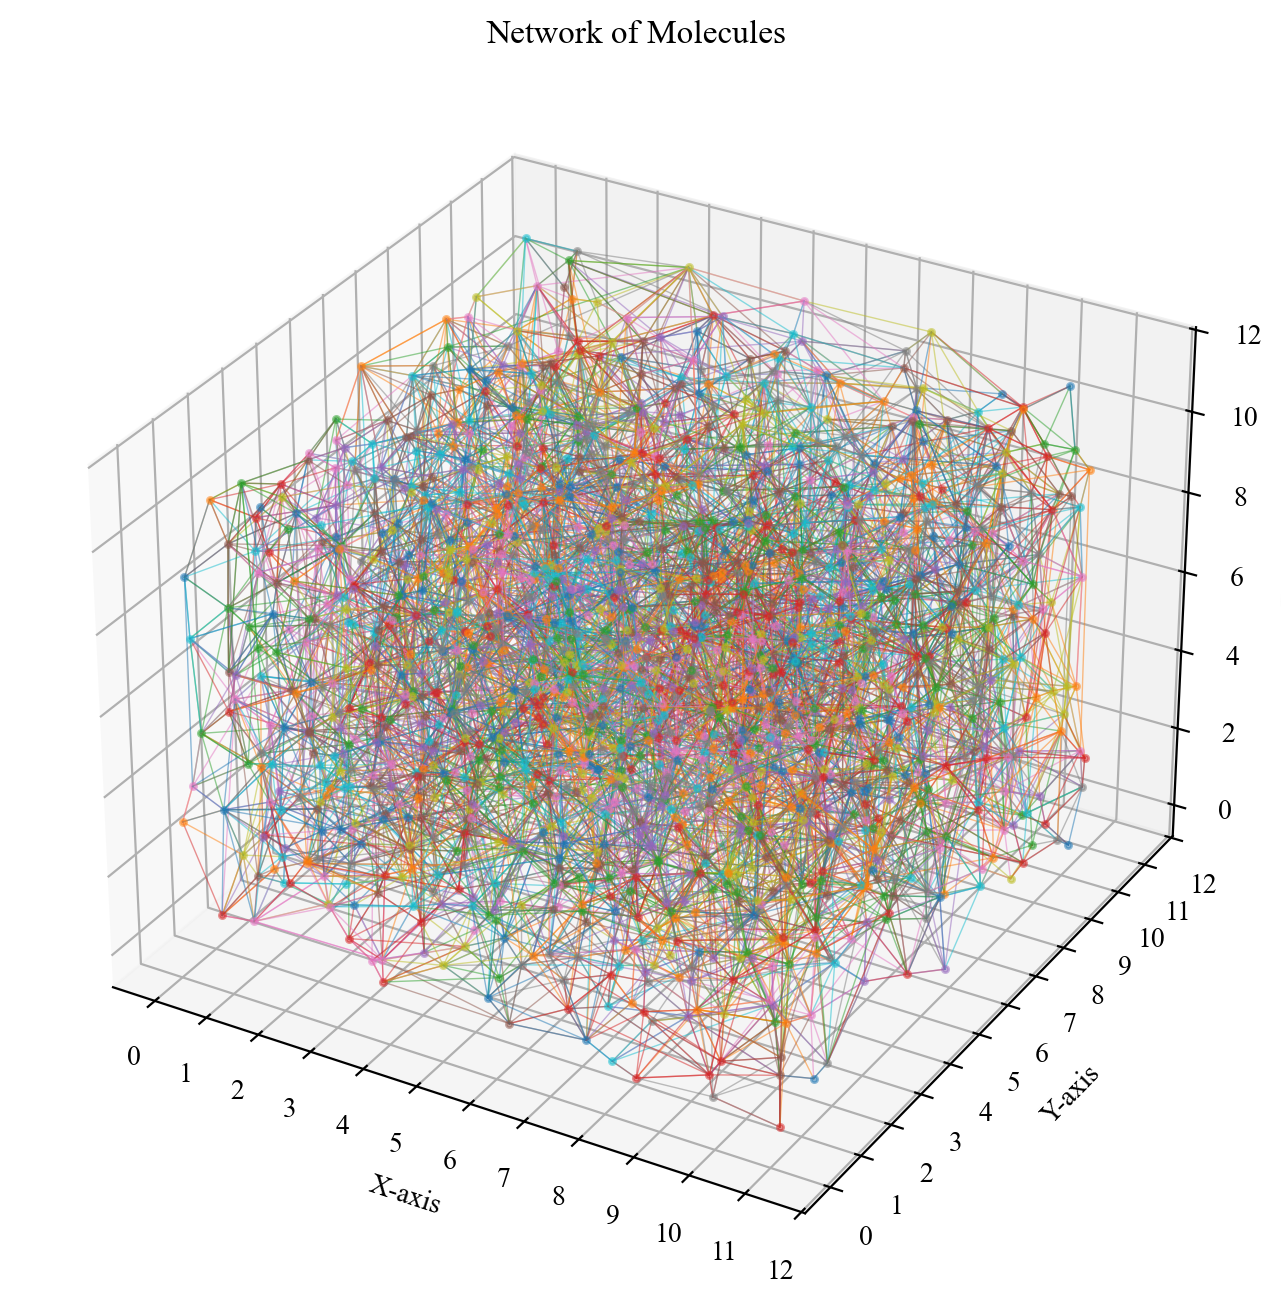

In [8]:
# --------------------------------------
# Graph Plotting
# --------------------------------------

# Create a scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.set_title('Network of Molecules')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')

# Axes configuration
# ax.axvline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.7)
# ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.7)
# ax.set_xlim(low - 1, high + 1)
# ax.set_ylim(low - 1, high + 1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=1))

ax.grid(True, alpha=0.3)
num_edge = 0

for i, node_neighbors in enumerate(nodes_neighbors):
    # Selected node
    node_x, node_y, node_z = x[i], y[i], z[i]
    
    # Add a node (scatter)
    scatter_plot = ax.scatter(node_x, node_y, node_z, s=5, label=f'Node {i+1}', alpha=0.5) 
    current_color = scatter_plot.get_facecolor()[0]
    
    # Plot Edges (Lines)
    for node in node_neighbors:
        ax.plot([node_x, node[0]], [node_y, node[1]], [node_z, node[2]], marker='None', lw=0.5, color=current_color, alpha=0.5)
        num_edge += 1    

# Prevent duplicate plots
# plt.legend()
plt.show()


### Plotly Visualisation **(RUN AT YOUR OWN RISK OF CRASHING JUPYTER)**

In [9]:
# # --------------------------------------
# # Graph Plotting
# # --------------------------------------

# # Low level 3D plotting using Plotly
# import plotly.graph_objects as go
# # High level plotting (used for color here)
# import plotly.express as px

# # Parameters
# size = 10   # x,y,z axes limits

# # Create a layout dictionary for the title and axes
# layout = go.Layout(
#     # Figure size
#     # width=1000,
#     # height=800,
#     width=800,
#     height=600,
    
#     # Title
#     title=dict(
#         text="3D Scatter Plot from NumPy Arrays",
#         font=dict(
#             family="Helvetica, Times New Roman",
#             size=20,
#             color="black"
#         ),
#         # Positioning the title
#         y=0.9,
#         x=0.5,
#         xanchor='center',
#         yanchor='top',
#     ),
#     # Axes
#     scene=dict(
#         xaxis_title="X-axis",
#         yaxis_title="Y-axis",  
#         zaxis_title="Z-axis",
#         xaxis=dict(range=[-size, size]),
#         yaxis=dict(range=[-size, size]),
#         zaxis=dict(range=[-size, size]),
#     ),
#     # Font settings
#     font=dict(
#         family="Lato, Times New Roman",
#         size=14,
#         color="black"
#     ),
#     # Legend
#     legend=dict(
#         x=0.975,
#         y=1,
#         xanchor='right',
#         yanchor='top',
#         bordercolor='black',
#         bgcolor='#E5ECF6',
#         borderwidth=1,
#         itemclick='toggleothers',
#         # itemclick='toggle'  # Enables the hover effect with a shadow
#     )
# )

# # Combine the trace and layout into a single Figure object
# fig = go.Figure(data=[], layout=layout)

# # Select a color sequence from Plotly Express
# color_sequence = px.colors.qualitative.Plotly
# num_colors = len(color_sequence)

# # Drawing edges
# for i, node_neighbors in enumerate(nodes_neighbors):
#     # Use a color from the sequence, cycling if needed
#     current_color = color_sequence[i % num_colors]
    
#     # Selected node
#     node_x, node_y, node_z = x[i], y[i], z[i]
    
#     # Add a node (scatter)
#     fig.add_trace(go.Scatter3d(
#         x=[node_x],
#         y=[node_y],
#         z=[node_z],
#         mode='markers',
#         marker=dict(size=3, color=current_color, opacity=1),
#         name=f'Node {i+1}',
#         # visible='legendonly'
#     ))
    
#     # Plot Edges (Lines)
#     # Iterate through each neighbor's coordinates to draw an edge (line)
#     for node in node_neighbors:
#         fig.add_trace(go.Scatter3d(
#             x=[node_x, node[0]],
#             y=[node_y, node[1]],
#             z=[node_z, node[2]],
#             mode='lines',
#             opacity=0.5,
#             line=dict(width=1, color=current_color),
#             showlegend=True,
#             # visible='legendonly',
#         ))
    
# # Set the x, y and z axis
# line_range = [-box_length, box_length]
# fig.add_trace(go.Scatter3d(
#     x=line_range,
#     y=[0, 0],
#     z=[0, 0],
#     mode='lines',
#     line=dict(color='black', width=2, dash='longdash'),
#     showlegend=False,
# ))
# fig.add_trace(go.Scatter3d(
#     x=[0, 0],
#     y=line_range,
#     z=[0, 0],
#     mode='lines',
#     line=dict(color='black', width=2, dash='longdash'),
#     showlegend=False,
# ))
# fig.add_trace(go.Scatter3d(
#     x=[0, 0],
#     y=[0, 0],
#     z=line_range,
#     mode='lines',
#     line=dict(color='black', width=2, dash='longdash'),
#     showlegend=False,
# ))

# # Tight layout
# fig.update_layout(margin=dict(l=0, r=0, b=40, t=60))
# fig.show()

## c) Error In 3-D Modelling

Ignore the messy code, just play around with the `plotly` output to see the **blocking error**.

In [10]:
# Create simple data
# n, low, high = 30, -5, 5
# x = np.array(np.random.uniform(low=low, high=high, size=n))
# y = np.array(np.random.uniform(low=low, high=high, size=n))
# z = np.array(np.random.uniform(low=low, high=high, size=n))

# x = np.array([-2, 6, -1, -2, 1, 3, 3, 3, 5, 6, 0])
# y = np.array([-2, -2, -1, 6, 1, 3, 3, 3, 5, 6, 0])
# z = np.array([6, -2, -1, -2, 1, 1, 3, 5, 5, 6, 3.70])

# Bug: For cases where a neighbor is very close and blocking top (θ), incorrectly 'ignores' blocking neighbor
x = np.array([0, 0, 0, -0.7, -0.7, 2, 4])
y = np.array([0, 0, 0, -0.7, 0.7, 0, 0])
z = np.array([0, 2, -2, -4, 4, 0, 0])

node = [0,0,-2]
dl = 2 # Width of a node (cm)

# Keep original for later plotting
x_copy = x.copy()
y_copy = y.copy()
z_copy = z.copy()


# Get sorted distances and indices
distances, indices = find_sort_neighbors_distances(node, x, y, z)
# Sort x, y, z, distances. Then removes first element (the node itself)
x, y, z, distances = x[indices], y[indices], z[indices], distances[indices]
x, y, z, distances = np.delete(x, 0), np.delete(y, 0), np.delete(z, 0), np.delete(distances, 0)
# Get sorted thetas
thetas = find_thetas(node, z, distances)
# Get sorted phis
phis = find_phis(node, x, y)
# Keep z[indices] copy for plotting neighbors
z_indices_copy = z.copy()


# !!! Get the blocking portion in thetas θ !!!
d_theta = np.arctan(dl / (2 * distances))
block1_thetas, block2_thetas = thetas - d_theta, thetas + d_theta
# Get the blocking portion, dx & dy of each neighbor nodes
dx_theta = (dl/2) * np.cos(thetas) * np.cos(phis)
dy_theta = (dl/2) * np.cos(thetas) * np.sin(phis)
dz_theta = (dl/2) * np.sin(thetas)
# Get the blocking portion in cartesian coordinates
block1_x_thetas, block1_y_thetas, block1_z_thetas = x - dx_theta, y - dy_theta, z + dz_theta
block2_x_thetas, block2_y_thetas, block2_z_thetas = x + dx_theta, y + dy_theta, z - dz_theta


# Get the blocking portion, dx & dy of each neighbor nodes
dx, dy = dl/2 * np.sin(phis), dl/2 * np.cos(phis)
block1_x_phis, block1_y_phis = x + dx, y - dy
block2_x_phis, block2_y_phis = x - dx, y + dy
# !!! Get the blocking portion in phis Φ !!!
block1_phis, block2_phis = find_phis(node, block1_x_phis, block1_y_phis), find_phis(node, block2_x_phis, block2_y_phis)


# Converting phis to 0 < Φ < 2π
phis = np.where(phis < 0, phis + 2 * np.pi, phis)
block1_phis = np.where(block1_phis < 0, block1_phis + 2 * np.pi, block1_phis)
block2_phis = np.where(block2_phis < 0, block2_phis + 2 * np.pi, block2_phis)
# Correcting for Φ1 = 350° and Φ2 = 10°
block2_phis = np.where(block1_phis > block2_phis, block2_phis + 2 * np.pi, block2_phis)

# Thetas are between 0 < θ < π
# Correcting for Φ1 = 350° and Φ2 = 10°

# Determines the indices of the nodes that are blocked
all_blocked_indices = []
for i in range(len(block1_phis)):
    # Checks if ((Φ1 < Φ < Φ2) | (Φ1 < Φ + 2π < Φ2)) &
    # Checks if (θ1 < θ1 < θ2) &
    # Checks if (node distance > current node distance)
    blocked_indices = np.where(
        (((phis >= block1_phis[i]) & (phis <= block2_phis[i])) | ((phis + 2*np.pi >= block1_phis[i]) & (phis + 2*np.pi <= block2_phis[i])) )&# | ((thetas > block1_thetas[i]) & (thetas < block2_thetas[i]))) &
        ((thetas >= block1_thetas[i]) & (thetas <= block2_thetas[i])) &
        (distances > distances[i])
        )[0]
    
    # print(f'Loop {i+1} -------------')
    # print(f'Blocked indices: {blocked_indices}')
    # print(f'x: {x}')
    # print(f'y: {y}')
    
    all_blocked_indices.extend(blocked_indices)
        

# Remove duplicate indices
all_blocked_indices = np.unique(all_blocked_indices)
try:
    x = np.delete(x, all_blocked_indices)
    y = np.delete(y, all_blocked_indices)
    z = np.delete(z, all_blocked_indices)
except IndexError:
    # Fix problem: all_blocked_indices is empty ndarray
    pass


# Debug
# print(f'x: {x}')
# print(f'y: {y}')
# print(f'z: {z}')
# print(f'blocked_indices: {all_blocked_indices}')
# print(f'distances: {distances}')
# print(f'thetas: {thetas * 180 / np.pi}')
# print(f'block1_thetas: {block1_thetas * 180 / np.pi}')
# print(f'block2_thetas: {block2_thetas * 180 / np.pi}')
# print(f'phis: {phis * 180 / np.pi}')
# print(f'block1_phis: {block1_phis * 180 / np.pi}')
# print(f'block2_phis: {block2_phis * 180 / np.pi}')



In [11]:
# Low level 3D plotting using Plotly
import plotly.graph_objects as go

# Parameters
size = 7

# Create a trace for the data
neighbors = go.Scatter3d(
    x=x_copy, y=y_copy, z=z_copy,
    name='Neighbors',
    mode='markers',  # Pure points (no lines)
    marker=dict(
        size=5,     
        color='purple', # Color by z-value (optional)
        opacity=0.8
    ),
)
data_point = go.Scatter3d(
    x=[node[0]], y=[node[1]], z=[node[2]],
    name='Data Points',
    mode='markers',  # Pure points (no lines)
    marker=dict(
        size=5,     
        color='blue', # Color by z-value (optional)
        opacity=1
    ),
)
# Blocking thetas
phi1 = go.Scatter3d(
    x=block1_x_phis, y=block1_y_phis, z=z_indices_copy,
    name=r'Blocking Φ₁',
    mode='markers',  # Pure points (no lines)
    marker=dict(
        size=5,     
        color='red', # Color by z-value (optional)
        opacity=0.8
    ),
)
phi2 = go.Scatter3d(
    x=block2_x_phis, y=block2_y_phis, z=z_indices_copy,
    name=r'Blocking Φ₂',
    mode='markers',  # Pure points (no lines)
    marker=dict(
        size=5,     
        color='green', # Color by z-value (optional)
        opacity=0.8
    ),
)
theta1 = go.Scatter3d(
    x=block1_x_thetas, y=block1_y_thetas, z=block1_z_thetas,
    name=r'Blocking θ₁',
    mode='markers',  # Pure points (no lines)
    marker=dict(
        size=5,     
        color='orange', # Color by z-value (optional)
        opacity=0.8
    ),
)
theta2 = go.Scatter3d(
    x=block2_x_thetas, y=block2_y_thetas, z=block2_z_thetas,
    name=r'Blocking θ₂',
    mode='markers',  # Pure points (no lines)
    marker=dict(
        size=5,     
        color='brown', # Color by z-value (optional)
        opacity=0.8
    ),
)

# Create a layout dictionary for the title and axes
layout = go.Layout(
    # Figure size
    # width=1000,
    # height=800,
    width=800,
    height=600,
    
    # Title
    title=dict(
        text="3D Scatter Plot from NumPy Arrays",
        font=dict(
            family="Helvetica, Times New Roman",
            size=20,
            color="black"
        ),
        # Positioning the title
        y=0.9,
        x=0.5,
        xanchor='center',
        yanchor='top',
    ),
    # Axes
    scene=dict(
        xaxis_title="X-axis",
        yaxis_title="Y-axis",  
        zaxis_title="Z-axis",
        xaxis=dict(range=[-size, size]),
        yaxis=dict(range=[-size, size]),
        zaxis=dict(range=[-size, size]),
    ),
    # Font settings
    font=dict(
        family="Lato, Times New Roman",
        size=14,
        color="black"
    ),
    # Legend
    legend=dict(
        x=0.975,
        y=1,
        xanchor='right',
        yanchor='top',
        bordercolor='black',
        bgcolor='#E5ECF6',
        borderwidth=1,
        itemclick='toggleothers'  # Enables the hover effect with a shadow
    )
)

# Combine the trace and layout into a single Figure object
fig = go.Figure(data=[data_point, neighbors, phi1, phi2, theta1, theta2], layout=layout)

# Drawing edges
for i in range(len(x)):
    # Add a trace for the line
    fig.add_trace(go.Scatter3d(
        x=[node[0], x[i]], 
        y=[node[1], y[i]], 
        z=[node[2], z[i]],
        mode='lines',
        name=f'Nearest {i+1}',
        line=dict(width=4),
    ))

# Set the x, y and z axis
line_range = [-size, size]
fig.add_trace(go.Scatter3d(
    x=line_range,
    y=[0, 0],
    z=[0, 0],
    mode='lines',
    line=dict(color='black', width=2, dash='longdash'),
    showlegend=False,
))
fig.add_trace(go.Scatter3d(
    x=[0, 0],
    y=line_range,
    z=[0, 0],
    mode='lines',
    line=dict(color='black', width=2, dash='longdash'),
    showlegend=False,
))
fig.add_trace(go.Scatter3d(
    x=[0, 0],
    y=[0, 0],
    z=line_range,
    mode='lines',
    line=dict(color='black', width=2, dash='longdash'),
    showlegend=False,
))

# Tight layout
fig.update_layout(margin=dict(l=0, r=0, b=40, t=60))
fig.show()

---

## D) 2-D Modelling

Algorithm for blocking and finding neighbors. Below are the implementation
- **Works perfectly with no errors!**

In [12]:
def find_sort_neighbors_distances_2D(node: list, x: np.ndarray, y: np.ndarray) -> tuple:
    """
    Calculate Euclidean distances of all neighbors from a given node in 2D space, alongside an ndarray of sorted indices from closest to furthest.
    
    Parameters:
    node (array-like): Coordinates of node [x, y].
    x (np.ndarray)   : x-coordinates of neighbors.
    y (np.ndarray)   : y-coordinates of neighbors.
    
    Returns:
    tuple: Unsorted distances and sorted indices from closest to furthest of the nearest neighbors.
    """
    # Calculate Euclidean distances of all neighbors from the node
    distances = LA.norm(np.array([x - node[0], y - node[1]]), axis=0)
    
    # Returns unsorted distances and their indices
    return np.sort(distances), np.argsort(distances)

def find_phis(node: list, x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Calculate the angle phi (Φ) of each neighbor, with respect to a selected node in a 3D space.

    Parameters:
    node (list): Coordinates of the reference node [x, y].
    x (np.ndarray): x-coordinates of neighbors.
    y (np.ndarray): y-coordinates of neighbors.

    Returns:
    np.ndarray: Array of angles (in radians) of each neighbor, with respect to a selected node.
    """
    phis = np.arctan2(y - node[1], x - node[0])
    return phis

Randomly generate nodes to visualise blocking.

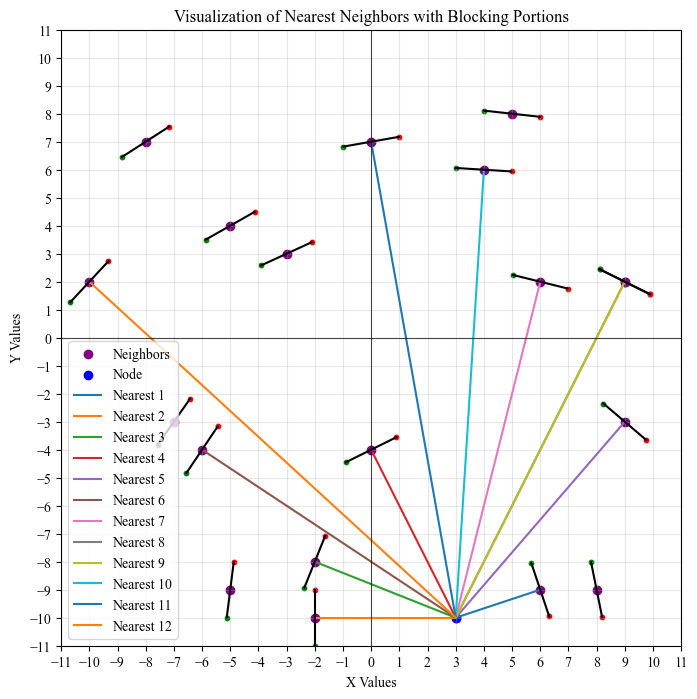

In [13]:
# --------------------------------------
# Data & Calculations
# --------------------------------------

# Reduce figure size
plt.rcParams['figure.dpi'] = 100

# Create random data
arr_size, low_bound, high_bound,  = 20, -10, 10
x = np.random.randint(low=low_bound, high=high_bound, size=arr_size)
y = np.random.randint(low=low_bound, high=high_bound, size=arr_size)

# Sample a random node
xy = np.column_stack((x, y))
num_rows = xy.shape[0]
random_row_index = np.random.randint(0, num_rows)
node = xy[random_row_index].tolist()
dl = 2 # Width of a node (cm)

# Keep original for later plotting
x_copy = x.copy()
y_copy = y.copy()


# Get sorted distances and indices
distances, indices = find_sort_neighbors_distances_2D(node, x, y)
# Sort x, y. Then removes first element (the node itself)
x, y = x[indices], y[indices]
x, y, distances = np.delete(x, 0), np.delete(y, 0), np.delete(distances, 0)
# Get sorted phis
phis = find_phis(node, x, y)


# Get the blocking portion, dx & dy of each neighbor nodes
dx, dy = dl/2 * np.sin(phis), dl/2 * np.cos(phis)
block1_x, block1_y = x + dx, y - dy
block2_x, block2_y = x - dx, y + dy
# Get the blocking portion in phis
block1_phis, block2_phis = find_phis(node, block1_x, block1_y), find_phis(node, block2_x, block2_y)

# Converting phis to 0 < Φ < 2π
phis = np.where(phis < 0, phis + 2 * np.pi, phis)
block1_phis = np.where(block1_phis < 0, block1_phis + 2 * np.pi, block1_phis)
block2_phis = np.where(block2_phis < 0, block2_phis + 2 * np.pi, block2_phis)
# Correcting for θ1 = 350° and θ2 = 10°
block2_phis = np.where(block1_phis > block2_phis, block2_phis + 2 * np.pi, block2_phis)


# Determines the indices of the nodes that are blocked
all_blocked_indices = []
for i in range(len(block1_phis)):
    # Checks if ((Φ1 < Φ < Φ2) | (Φ1 < Φ + 2π < Φ2)) & (node distance > current node distance)
    blocked_indices = np.where(
        (((phis >= block1_phis[i]) & (phis <= block2_phis[i])) | ((phis + 2*np.pi >= block1_phis[i]) & (phis + 2*np.pi <= block2_phis[i]))) &
        (distances > distances[i]))[0]

    all_blocked_indices.extend(blocked_indices)
        

# Remove duplicate indices
all_blocked_indices = np.unique(all_blocked_indices)
x = np.delete(x, all_blocked_indices)
y = np.delete(y, all_blocked_indices)


# --------------------------------------
# Graph Plotting
# --------------------------------------

# Create a scatter plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(x_copy, y_copy, color='purple', label='Neighbors')
ax.scatter(node[0], node[1], color='blue', label='Node')
for i in range(len(x)):
    ax.plot([node[0], x[i]], [node[1], y[i]], label=f'Nearest {i+1}')
    
# Draw blocking portion of nodes
for i in range(len(block1_x)):
    ax.scatter(block1_x[i], block1_y[i], color='red', s=10)
    ax.scatter(block2_x[i], block2_y[i], color='green', s=10)
    ax.plot([block1_x[i], block2_x[i]], [block1_y[i], block2_y[i]], color='black', linestyle='-', marker='')


plt.title('Visualization of Nearest Neighbors with Blocking Portions')
plt.xlabel('X Values')
plt.ylabel('Y Values')

# Axes configuration
ax.axvline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.7)
ax.set_xlim(low_bound - 1, high_bound + 1)
ax.set_ylim(low_bound - 1, high_bound + 1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=1))

# plt.savefig("./images/02_method_2_blocking_visualization.png", dpi=300)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Find neighbors for all nodes. Uncomment to visualise step by step. 

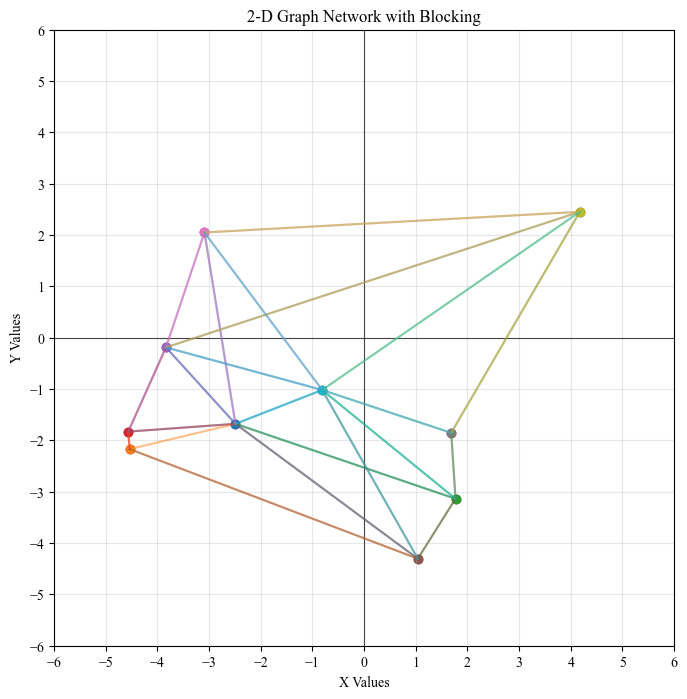

In [15]:
# --------------------------------------
# Data & Calculations
# --------------------------------------

# Reduce figure size
plt.rcParams['figure.dpi'] = 100

# Seed for reproducibility
np.random.seed(41)

# Create random data
dl = 2 # Width of a node (cm)
arr_size, low_bound, high_bound,  = 10, -5, 5
x = np.random.uniform(low=low_bound, high=high_bound, size=arr_size)
y = np.random.uniform(low=low_bound, high=high_bound, size=arr_size)
# Keep original for later plotting
x_copy = x.copy()
y_copy = y.copy()
# Stacks the x and y coordinates into a 2D array
xy = np.column_stack((x, y))


# Loop through every node and find their respective neighbors
nodes_neighbors = []
for nodes in xy:
    # Converts current node to a list
    node = nodes.tolist()
    # Get sorted distances and indices
    distances, indices = find_sort_neighbors_distances_2D(node, x, y)
    # Sort x, y. Then removes first element (the node itself)
    x_temp, y_temp = x[indices], y[indices]
    x_temp, y_temp, distances = np.delete(x_temp, 0), np.delete(y_temp, 0), np.delete(distances, 0)
    # Get sorted phis
    phis = find_phis(node, x_temp, y_temp)


    # Get the blocking portion, dx and dy of each neighbor nodes
    dx, dy = dl/2 * np.sin(phis), dl/2 * np.cos(phis)
    block1_x, block1_y = x_temp + dx, y_temp - dy
    block2_x, block2_y = x_temp - dx, y_temp + dy
    # Get the blocking portion in phis
    block1_phis, block2_phis = find_phis(node, block1_x, block1_y), find_phis(node, block2_x, block2_y)

    # Converting phis to 0 < Φ < 2π
    phis = np.where(phis < 0, phis + 2 * np.pi, phis)
    block1_phis = np.where(block1_phis < 0, block1_phis + 2 * np.pi, block1_phis)
    block2_phis = np.where(block2_phis < 0, block2_phis + 2 * np.pi, block2_phis)
    # Correcting for Φ1 = 350° and Φ2 = 10°
    block2_phis = np.where(block1_phis > block2_phis, block2_phis + 2 * np.pi, block2_phis)

    # Determines the indices of the nodes that are blocked
    all_blocked_indices = []
    for i in range(len(block1_phis)):
        # Checks if ((Φ1 < θ < Φ2) | (θ1 < θ + 2π < Φ2)) & (node distance > current node distance)
        blocked_indices = np.where((((phis >= block1_phis[i]) & (phis <= block2_phis[i])) |
                                    ((phis + 2*np.pi >= block1_phis[i]) & (phis + 2*np.pi <= block2_phis[i]))) &
                                    (distances > distances[i]))[0]

        all_blocked_indices.extend(blocked_indices)
            

    # Remove duplicate indices
    all_blocked_indices = np.unique(all_blocked_indices)
    try:
        x_temp = np.delete(x_temp, all_blocked_indices)
        y_temp = np.delete(y_temp, all_blocked_indices)
    except IndexError:
        pass
    
    # Appends the node and its neighbors to the list
    nodes_neighbors.append([x_temp, y_temp])


# --------------------------------------
# Graph Plotting
# --------------------------------------

from IPython.display import display, clear_output

# Create a scatter plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(x_copy, y_copy, color='purple')

plt.title('2-D Graph Network with Blocking')
plt.xlabel('X Values')
plt.ylabel('Y Values')

# Axes configuration
ax.axvline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.7)
ax.set_xlim(low_bound - 1, high_bound + 1)
ax.set_ylim(low_bound - 1, high_bound + 1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=1))

ax.grid(True, alpha=0.3)


# ---------------------------------
# COMMENT FOR INTERACTIVITY
# ---------------------------------

for i, node_neighbors in enumerate(nodes_neighbors):
    # Plot Scatter
    scatter_plot = ax.scatter(x[i], y[i], label=f'Node {i+1}')
    
    # Jargon for lines
    x_temp2, y_temp2 = np.full(node_neighbors[0].shape, x[i]), np.full(node_neighbors[1].shape, y[i])    
    current_color = scatter_plot.get_facecolor()[0]
    
    # Plot Lines
    ax.plot([x_temp2, node_neighbors[0]], [y_temp2, node_neighbors[1]], marker='None', color=current_color, alpha=0.5)
    
plt.show()

# ---------------------------------
    
    
# ---------------------------------
# UNCOMMENT FOR INTERACTIVITY
# ---------------------------------

# for i, node_neighbors in enumerate(nodes_neighbors):
#     # Clear the previous output
#     clear_output(wait=True)
    
#     # Plot Scatter
#     scatter_plot = ax.scatter(x[i], y[i], label=f'Node {i+1}')
    
#     # Jargon for lines
#     x_temp2, y_temp2 = np.full(node_neighbors[0].shape, x[i]), np.full(node_neighbors[1].shape, y[i])    
#     current_color = scatter_plot.get_facecolor()[0]
    
#     # Plot Lines
#     ax.plot([x_temp2, node_neighbors[0]], [y_temp2, node_neighbors[1]], marker='None', color=current_color, alpha=0.5)
    
#     # Updates the legend and fig
#     plt.legend()
#     display(fig)
    
#     # Interactivity, breaks loop if user knows how to exit Vim
#     user_input = input('Next Node? Press Any Key to Continue. To quit, exit Vim.')
#     if user_input in [":q", ":wq", ":q!", ":x", ":qa", ":wqa", ":xall", "ZZ", "ZQ", ":exit"]:
#         break

# # Prevent duplicate plots
# plt.close()

# ---------------------------------